# IDS Multiclasse com `content_ext` — SOME/IP (5 classes)

> ⚠️ **Split ALEATÓRIO — número ilustrativo, não o resultado in-scope.**
> Este notebook usa `train_test_split` 70/30, então o **macro-F1 ≈ 0,99 é otimista**
> (vazamento temporal — pacotes da mesma rajada em treino e teste). Ele serve para a
> **comparação justa Kim-12 vs `content_ext`** (mesmo protocolo → comparação relativa válida),
> **não** para reportar desempenho absoluto.
>
> Para os números **honestos**, use:
> - **`00-pipeline-completo.ipynb`** — pipeline ponta a ponta com **split temporal** (macro-F1 **0,966**);
> - **`02-comparacao-splits.ipynb`** — aleatório vs temporal lado a lado;
> - **`03-params-kim-gpu.ipynb`** — robustez aos hiperparâmetros (params do Kim, GPU);
> - generalização a **ataque novo**: zero-day ~0,60 (`someip-ids-benchmark`).

Classifica em `normal, dos, fuzzy, mitm_single, mitm_multi` usando as features **content_ext**
(12 do Kim + `repeat_rate`, `someip_len`, `l4_len`, `src_payload_div`) — **sem features de
header**, evitando o overfitting que elas causam (ver `docs/relatorio-grupos-features.md`).

Split **70/30 estratificado**. Saídas: métricas por classe, matriz de confusão, curvas ROC/PR.

Resultado de referência: **macro-F1 ≈ 0,99** (vs. 0,78 com as 12 puras do Kim). Os gargalos
`fuzzy` (0,50→0,998) e `mitm_multi` (0,57→0,989) somem — eram problema de **features**, não de
modelo. Ver `docs/relatorio-multiclasse.md`.

> Dados em `data/ours_ext/X.npz` (21 features) e `data/ours_ext/y_multi.npz`, gerados por
> `python src/extract_ext.py`. No Colab, suba os dois `.npz`.

In [1]:
import numpy as np, json, os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc,
                             precision_recall_curve, average_precision_score)
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier

CLASSES = ['normal','dos','fuzzy','mitm_single','mitm_multi']; N=len(CLASSES); SEED=0
DATA = 'data/ours_ext' if os.path.exists('data/ours_ext') else '../data/ours_ext'
# content_ext = 12 do Kim + repeat_rate(12), someip_len(13), l4_len(14), src_payload_div(16)
CONTENT_EXT = list(range(12)) + [12, 13, 14, 16]
print('content_ext:', len(CONTENT_EXT), 'features | DATA =', DATA)

content_ext: 16 features | DATA = ../data/ours_ext


In [2]:
names = json.load(open(f'{DATA}/feature_names.json'))
X = np.load(f'{DATA}/X.npz')['a'][:, CONTENT_EXT]
y = np.load(f'{DATA}/y_multi.npz')['a']
print('features usadas:', [names[i] for i in CONTENT_EXT])
print('X:', X.shape, '| classes:', dict(zip(*[v.tolist() for v in np.unique(y, return_counts=True)])))

features usadas: ['ip_time_interval', 'someip_loglik', 'sd_loglik', 'l4_loglik', 'someip_entropy', 'sd_entropy', 'l4_entropy', 'someip_change', 'sd_change', 'l4_change', 'ip_len_change', 'l4_len_change', 'repeat_rate', 'someip_len', 'l4_len', 'src_payload_div']
X: (14233354, 16) | classes: {0: 12578355, 1: 306944, 2: 560052, 3: 360510, 4: 427493}


In [3]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.30, random_state=SEED, stratify=y)
print(f'treino={X_tr.shape[0]:,}  teste={X_te.shape[0]:,}')

clf = XGBClassifier(objective='multi:softprob', num_class=N,
                    n_estimators=300, max_depth=8, learning_rate=0.3,
                    tree_method='hist', max_bin=256, n_jobs=-1, eval_metric='mlogloss')
clf.fit(X_tr, y_tr)
proba = clf.predict_proba(X_te)
y_pred = proba.argmax(axis=1)
print('treino concluído')

treino=9,963,347  teste=4,270,007


treino concluído


In [4]:
print(classification_report(y_te, y_pred, target_names=CLASSES, digits=4))

              precision    recall  f1-score   support

      normal     0.9991    0.9998    0.9995   3773507
         dos     0.9864    0.9954    0.9909     92083
       fuzzy     0.9988    0.9969    0.9979    168016
 mitm_single     0.9964    0.9859    0.9911    108153
  mitm_multi     0.9973    0.9807    0.9889    128248

    accuracy                         0.9987   4270007
   macro avg     0.9956    0.9917    0.9936   4270007
weighted avg     0.9987    0.9987    0.9987   4270007



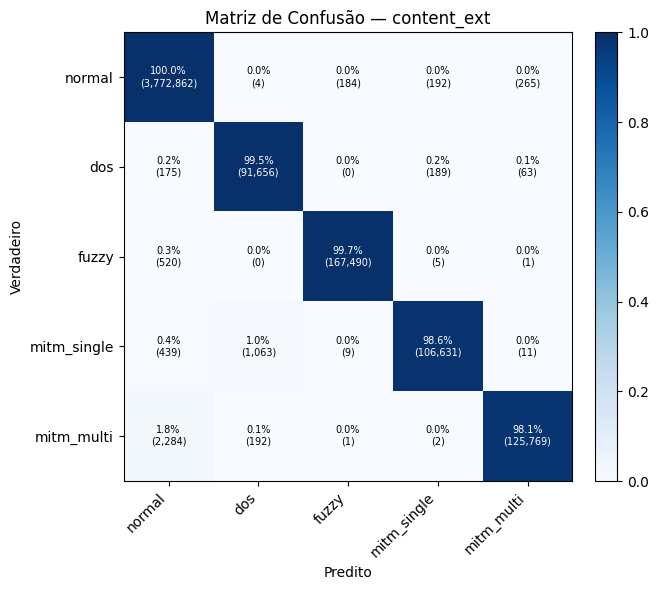

In [5]:
# Matriz de confusão (normalizada por linha)
cm = confusion_matrix(y_te, y_pred); cmn = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(7,6)); im = ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(N)); ax.set_yticks(range(N))
ax.set_xticklabels(CLASSES, rotation=45, ha='right'); ax.set_yticklabels(CLASSES)
ax.set_xlabel('Predito'); ax.set_ylabel('Verdadeiro'); ax.set_title('Matriz de Confusão — content_ext')
for i in range(N):
    for j in range(N):
        ax.text(j, i, f'{cmn[i,j]*100:.1f}%\n({cm[i,j]:,})', ha='center', va='center',
                fontsize=7, color='white' if cmn[i,j]>0.5 else 'black')
fig.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

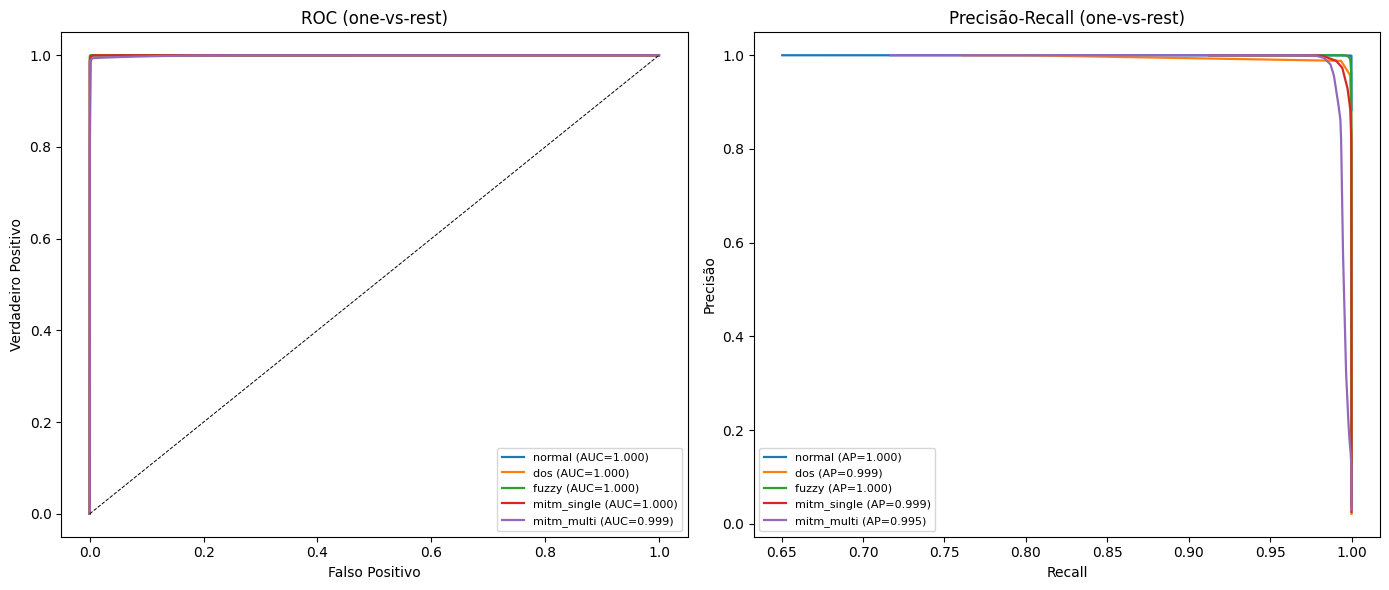

In [6]:
# Curvas ROC e Precisão-Recall (one-vs-rest)
yb = label_binarize(y_te, classes=range(N))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))
for i, name in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(yb[:,i], proba[:,i]); a = auc(fpr, tpr)
    s = max(len(fpr)//2000,1); ax1.plot(fpr[::s], tpr[::s], lw=1.6, label=f'{name} (AUC={a:.3f})')
    prec, rec, _ = precision_recall_curve(yb[:,i], proba[:,i]); ap = average_precision_score(yb[:,i], proba[:,i])
    s2 = max(len(rec)//2000,1); ax2.plot(rec[::s2], prec[::s2], lw=1.6, label=f'{name} (AP={ap:.3f})')
ax1.plot([0,1],[0,1],'k--',lw=0.7); ax1.set_xlabel('Falso Positivo'); ax1.set_ylabel('Verdadeiro Positivo')
ax1.set_title('ROC (one-vs-rest)'); ax1.legend(fontsize=8, loc='lower right')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precisão'); ax2.set_title('Precisão-Recall (one-vs-rest)')
ax2.legend(fontsize=8, loc='lower left'); plt.tight_layout(); plt.show()

## Leitura

- **macro-F1 ≈ 0,99** — todas as classes F1 ≥ 0,99; ROC-AUC ≈ 1,0.
- Os gargalos do baseline Kim-12 (`fuzzy` 0,50 e `mitm_multi` 0,57) **desaparecem** — eram
  limite de **features**, não de modelo.
- Conquistado **sem features de header** → sem o overfitting que elas causam, e mantendo o
  melhor zero-day (ver `docs/relatorio-grupos-features.md`).
- **Ressalva:** split aleatório 70/30 — número absoluto otimista (mesmo viés do `detection`
  com split aleatório). A comparação Kim-12 vs content_ext é justa (mesmo protocolo); o número
  robusto de generalização continua sendo o **zero-day**.